# Aridity Index Data for SHAP-Based Cluster Interpretation

This code supports the interpretation of cluster-wise SHAP analysis results targeting Pettitt-derived melt onset date (MOD) and melt end date (MED).

Since the physical characteristics of each cluster may not be immediately clear from SHAP values alone, an additional visualization of the study area using the Aridity Index (AI) is included to provide environmental context.

The Aridity Index dataset was downloaded from:
https://figshare.com/articles/dataset/Global_Aridity_Index_and_Potential_Evapotranspiration_ET0_Climate_Database_v2/7504448/5

This dataset provides high-resolution (30 arc-seconds) global raster data for the 1970–2000 period, representing climate conditions related to:
- evapotranspiration processes  
- rainfall deficit for potential vegetative growth  

To ensure consistency with our analysis, the original data were resampled to a 25 km spatial resolution to match the grid of the passive microwave dataset.

In [2]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
import shap
from lightgbm import LGBMRegressor
import seaborn as sns

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

/home/nayoung/miniconda3/envs/hydroAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create the land mask for regions north of 60°N

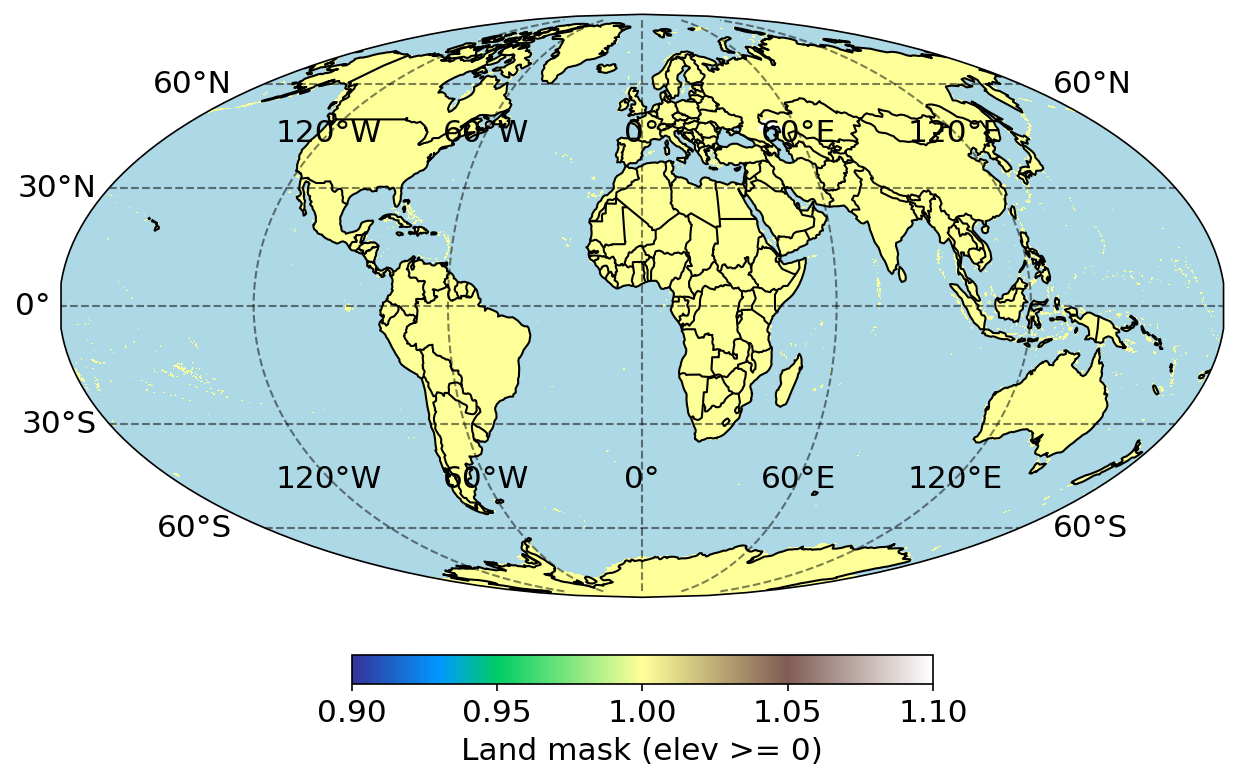

In [3]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Define functions to plot for the north of 60°N

In [4]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='both',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Convert the data from a TIFF file to a NetCDF file

In [4]:
# Paths
AI_tif_file_path = f'{cpuserver_data_FP}/personal_data/project_snow/Aridity_Index/Global-AI_ET0_v3_annual'
AI_nc_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index'
os.makedirs(AI_nc_file_path, exist_ok=True)

# Convert each TIFF to NC
filename = 'ai_v3_yr.tif'
tif_file_path = os.path.join(AI_tif_file_path, filename)

with rasterio.open(tif_file_path) as src:
    data = src.read(1).astype(np.float32)
    transform = src.transform

    lon = transform.c + (np.arange(src.width) + 0.5) * transform.a
    lat = transform.f + (np.arange(src.height) + 0.5) * transform.e

    if src.nodata is not None:
        data[data == src.nodata] = np.nan

    nc_filename = "AI_ET0_v3_annual.nc"
    nc_file_path = os.path.join(AI_nc_file_path, nc_filename)

    with nc.Dataset(nc_file_path, "w") as dst:
        dst.createDimension("lat", len(lat))
        dst.createDimension("lon", len(lon))

        var_name = "ai_v3_yr"
        print(var_name)
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        data_var = dst.createVariable(var_name, "f4", ("lat", "lon",))

        lat_var[:] = lat
        lon_var[:] = lon
        data_var[:, :] = data


ai_v3_yr


# Resample to 25km

In [5]:
AI_nc_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index'
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

for file in os.listdir(AI_nc_file_path):

    if file.startswith("."):
        continue

    if not file.endswith(".nc"):
        continue

    nc_file_path = os.path.join(AI_nc_file_path, file)

    with nc.Dataset(nc_file_path) as ds:
        lat = ds.variables['lat'][:]
        lon = ds.variables['lon'][:]
        data = ds.variables['ai_v3_yr'][:]
        print("Original data shape:", np.shape(data))

    # make 2D lon/lat
    lon_2d, lat_2d = np.meshgrid(lon, lat)

    # resample
    data_25km = hData.Resampling(domain_lon, domain_lat, lon_2d, lat_2d,
                                 data, 'nearest', 'mean', mag_factor=2)

    # Cut 60N on target grid
    row_idx = np.where(domain_lat[:, 0] >= 60)[0]
    data_25km_60N = data_25km[row_idx, :]
    
    # Apply land mask
    data_25km_60N = np.where(land_mask_60N_base, data_25km_60N, np.nan)

    print("Resampled data shape:", np.shape(data_25km_60N))

    # save the data to the nc file
    out_path = os.path.join(AI_nc_file_path, file.replace('.nc', '_60N.nc'))
    with nc.Dataset(out_path, "w") as dst:
        # use 1D coords
        lat_1d = domain_lat[row_idx, 0]
        lon_1d = domain_lon[0, :]

        dst.createDimension("lat", len(lat_1d))
        dst.createDimension("lon", len(lon_1d))

        lat_var = dst.createVariable("lat", "f4", ("lat",))
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        data_var = dst.createVariable(file.split("_")[0], "f4", ("lat", "lon",))

        lat_var[:] = lat_1d
        lon_var[:] = lon_1d
        data_var[:, :] = data_25km_60N

           

Original data shape: (21600, 43200)
Resampled data shape: (120, 1440)


## Vertify that the resampled Aridity Index map was generated correctly

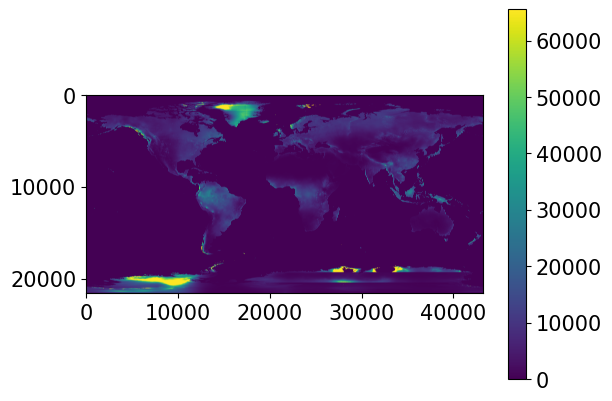

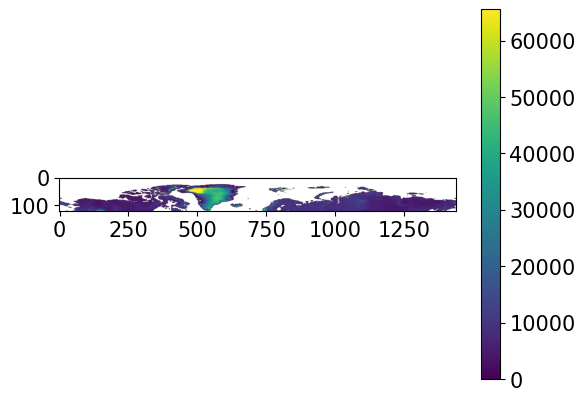

In [8]:
original_ncfile = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index/AI_ET0_v3_annual.nc'
resampled_ncfile = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index/AI_ET0_v3_annual_60N.nc'

with nc.Dataset(original_ncfile) as original_ds:
    original_lat = original_ds.variables['lat'][:]
    original_lon = original_ds.variables['lon'][:]
    original_data = original_ds.variables['ai_v3_yr'][:]

with nc.Dataset(resampled_ncfile) as resampled_ds:
    resampled_lat = resampled_ds.variables['lat'][:]
    resampled_lon = resampled_ds.variables['lon'][:]
    resampled_data = resampled_ds.variables['AI'][:]

plt.imshow(original_data)
plt.colorbar()
plt.show()

plt.imshow(resampled_data)
plt.colorbar()
plt.show()


## Figure 4. Plot the resampled Aridity Index map for the study area

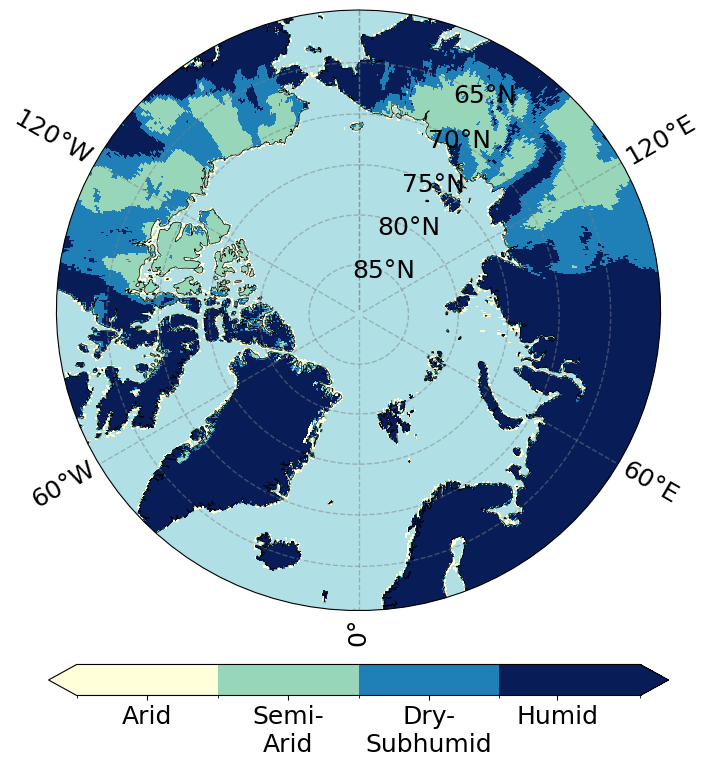

/home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index/AI_ET0_v3_annual_60N.png


In [5]:
# Since the Aridity Index values were scaled by a factor of 10,000, they need to be divided by 10,000.
resampled_ncfile = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index/AI_ET0_v3_annual_60N.nc'
with nc.Dataset(resampled_ncfile) as resampled_ds:
    resampled_lat = resampled_ds.variables['lat'][:]
    resampled_lon = resampled_ds.variables['lon'][:]
    resampled_data = resampled_ds.variables['AI'][:]/10000

outpath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index'
filename = os.path.join(outpath, "AI_ET0_v3_annual_60N.png")
ticks = [0.125, 0.35, 0.575, 1.0]
bounds = [0.05, 0.20, 0.50, 0.65, 1.50]
ticklabels = ['Arid', 'Semi-\nArid', 'Dry-\nSubhumid', 'Humid']

fig, ax = plot_Northpole(
    resampled_lon,
    resampled_lat,
    resampled_data,
    label_title=None,
    cmap='YlGnBu',
    vmin=0,
    vmax=1.5,
    bounds=[0.05,0.20,0.50,0.65,1.50],
    ticks=ticks,
    ticklabels=ticklabels
)

fig.savefig(filename, dpi=300, bbox_inches='tight')
print(filename)

## Examine the distribution of the Aridity Index for each cluster

In [6]:
# Define AI classes
def classify_ai(ai):
    conditions = [
        ai < 0.03,
        (ai >= 0.03) & (ai < 0.2),
        (ai >= 0.2) & (ai < 0.5),
        (ai >= 0.5) & (ai < 0.65),
        ai >= 0.65
    ]
    choices = [
        "Hyper-arid",
        "Arid",
        "Semi-arid",
        "Sub-humid",
        "Humid"
    ]
    return np.select(conditions, choices, default="Unknown")

In [7]:
Cluster_file = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
Aridity_file = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/Aridity_Index/AI_ET0_v3_annual_60N.nc'

# Open files
with nc.Dataset(resampled_ncfile) as resampled_ds:
    resampled_lat = resampled_ds.variables['lat'][:]
    resampled_lon = resampled_ds.variables['lon'][:]
    resampled_data = resampled_ds.variables['AI'][:]/10000

with nc.Dataset(Cluster_file) as Cluster_ds:
    Cluster_lat = Cluster_ds.variables['lat'][:]
    Cluster_lon = Cluster_ds.variables['lon'][:]
    Cluster_data = Cluster_ds.variables['TB_cluster'][:]

# Plot the Aridity Index for each cluster
cluster_id = [0, 1, 2]
ai_classes_order = ["Hyper-arid", "Arid", "Semi-arid", "Sub-humid", "Humid"]
results = []

for cid in cluster_id:
    mask = Cluster_data == cid
    ai_vals = resampled_data[mask]
    ai_vals = ai_vals[np.isfinite(ai_vals)]

    classes = classify_ai(ai_vals)
    class_counts = pd.Series(classes).value_counts(normalize=True) * 100

    for cls in ai_classes_order:
        results.append({
            "Cluster": f"Cluster {cid}",
            "AI class": cls,
            "Percentage (%)": class_counts.get(cls, 0)
        })

df_result = pd.DataFrame(results)

df_pivot = df_result.pivot(
    index="Cluster",
    columns="AI class",
    values="Percentage (%)"
)

df_pivot = df_pivot[ai_classes_order]

print("Percentage of each AI class in each cluster:")
display(df_pivot.round(2))


Percentage of each AI class in each cluster:


AI class,Hyper-arid,Arid,Semi-arid,Sub-humid,Humid
Cluster,,,,,
Cluster 0,0.00,0.02,13.47,14.12,72.39
Cluster 1,0.00,0.08,22.46,18.77,58.69
Cluster 2,0.02,0.08,30.64,38.14,31.12
